# Compare Action Landscapes Across Score Tiers

Measure what the scalar Ramsey score hides. The experiment keeps red and blue completion pressure separate and studies the complete 903-edge single-flip landscape at several archive score tiers plus random controls.

The goal is measurement first: identify features that change systematically as score falls before defining a new objective.

In [1]:
from pathlib import Path
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from ramsey import (
    RGraph,
    RMetricStore,
    RProblem,
    RRandomConstruction,
    RSQLiteArchive,
    RSearchState,
    calculate_metrics,
)
from ramsey.RActionLandscape import (
    calculate_action_landscape,
)

N_VERTICES = 43
RANDOM_SEED = 202_608_071
SAMPLES_PER_TIER = 20
RANDOM_SAMPLES = 20
RECOMPUTE_STORED_METRICS = False

SCORE_TIERS = (
    (0, 149),
    (150, 199),
    (200, 249),
    (250, 299),
    (300, 399),
    (400, 599),
)

project_root = Path.cwd().resolve()
if project_root.name == 'notebooks':
    project_root = project_root.parent

DATABASE_PATH = project_root / 'data' / 'ramsey_colorings.sqlite3'
rng = np.random.default_rng(RANDOM_SEED)

In [2]:
graph_start = perf_counter()
graph = RGraph(RProblem.r55(n_vertices=N_VERTICES))
graph_elapsed = perf_counter() - graph_start

archive = RSQLiteArchive(DATABASE_PATH)
metric_store = RMetricStore(DATABASE_PATH)
random_construction = RRandomConstruction(rng)

print('Database:', DATABASE_PATH.resolve())
print('Archive colorings:', archive.coloring_count(graph))
print('Archive best:', archive.best_score(graph))
print('Stored metric snapshots:', metric_store.count())
print('Graph setup:', f'{graph_elapsed:.3f}s')

Database: C:\code\RamseyNumber\data\ramsey_colorings.sqlite3
Archive colorings: 3261
Archive best: 129
Stored metric snapshots: 50
Graph setup: 1.430s


In [3]:
# Select independent samples from each archive tier.
selected = []

for minimum_score, maximum_score in SCORE_TIERS:
    records = archive.colorings_in_score_range(
        minimum_score=minimum_score,
        maximum_score=maximum_score,
        graph=graph,
    )

    if len(records) > SAMPLES_PER_TIER:
        indexes = rng.choice(
            len(records),
            size=SAMPLES_PER_TIER,
            replace=False,
        )
        records = [records[int(index)] for index in indexes]

    tier_name = f'{minimum_score}-{maximum_score}'
    selected.extend((tier_name, record) for record in records)
    print(tier_name, 'selected:', len(records))

print('Archived states selected:', len(selected))
print('Random controls:', RANDOM_SAMPLES)

0-149 selected: 20
150-199 selected: 20
200-249 selected: 0
250-299 selected: 20
300-399 selected: 20
400-599 selected: 20
Archived states selected: 100
Random controls: 20


In [4]:
# Calculate structural fingerprints and full single-edge landscapes.
# Metrics are persisted; action landscapes remain exactly reconstructible
# from a coloring and therefore are calculated on demand.

rows = []
snapshots = {}
landscapes = {}
analysis_start = perf_counter()

def analyze_state(state, *, tier, coloring_id=None):
    if (
        coloring_id is not None
        and not RECOMPUTE_STORED_METRICS
        and metric_store.contains(coloring_id)
    ):
        snapshot = metric_store.load(coloring_id).snapshot
    else:
        snapshot = calculate_metrics(state)
        if coloring_id is not None:
            metric_store.save(coloring_id, snapshot)

    landscape = calculate_action_landscape(state)
    key = coloring_id if coloring_id is not None else f'random-{len(rows):03d}'

    snapshots[key] = snapshot
    landscapes[key] = landscape

    rows.append({
        'state_id': key,
        'tier': tier,
        **snapshot.summary(),
        **{
            f'landscape_{name}': value
            for name, value in landscape.summary().items()
        },
    })

for index, (tier, record) in enumerate(selected, start=1):
    archived = archive.load_coloring(record.coloring_id, graph)
    state = RSearchState(archived.coloring)
    analyze_state(
        state,
        tier=tier,
        coloring_id=record.coloring_id,
    )
    print(
        f'{index:3d}/{len(selected):3d} | '
        f'id={record.coloring_id:5d} | score={state.score:4d} | {tier}'
    )

for random_index in range(RANDOM_SAMPLES):
    state = RSearchState(random_construction.construct(graph))
    analyze_state(state, tier='random')

analysis_elapsed = perf_counter() - analysis_start
landscape_frame = pd.DataFrame(rows)

print()
print('States analyzed:', len(landscape_frame))
print('Elapsed:', f'{analysis_elapsed:.3f}s')

  1/100 | id= 2652 | score= 146 | 0-149
  2/100 | id= 2837 | score= 147 | 0-149
  3/100 | id= 2796 | score= 149 | 0-149
  4/100 | id= 2946 | score= 146 | 0-149
  5/100 | id= 2893 | score= 146 | 0-149
  6/100 | id= 3063 | score= 138 | 0-149
  7/100 | id= 3189 | score= 140 | 0-149
  8/100 | id= 3100 | score= 138 | 0-149
  9/100 | id= 3198 | score= 145 | 0-149
 10/100 | id= 3035 | score= 148 | 0-149
 11/100 | id= 3048 | score= 144 | 0-149
 12/100 | id= 2961 | score= 146 | 0-149
 13/100 | id= 3004 | score= 143 | 0-149
 14/100 | id= 3122 | score= 148 | 0-149
 15/100 | id= 3088 | score= 147 | 0-149
 16/100 | id= 3027 | score= 149 | 0-149
 17/100 | id= 3234 | score= 143 | 0-149
 18/100 | id= 3196 | score= 137 | 0-149
 19/100 | id= 2985 | score= 147 | 0-149
 20/100 | id= 2870 | score= 146 | 0-149
 21/100 | id= 2346 | score= 168 | 150-199
 22/100 | id= 2842 | score= 151 | 150-199
 23/100 | id= 2282 | score= 164 | 150-199
 24/100 | id= 2147 | score= 169 | 150-199
 25/100 | id= 2205 | score= 174 

In [5]:
# Tier-level evolution. Keep the source tier order instead of sorting
# alphabetically so the table reads from frontier to random.
tier_order = [
    f'{minimum}-{maximum}'
    for minimum, maximum in SCORE_TIERS
] + ['random']

summary_columns = [
    'score',
    'red_violations',
    'blue_violations',
    'red_deficit_1',
    'blue_deficit_1',
    'max_vertex_violation_load',
    'max_edge_violation_load',
    'shared_edge_violation_pairs',
    'landscape_best_reward',
    'landscape_improving_actions',
    'landscape_neutral_actions',
    'landscape_mean_reward',
    'landscape_std_reward',
]

tier_summary = (
    landscape_frame
    .groupby('tier')[summary_columns]
    .agg(['mean', 'median', 'std', 'min', 'max'])
    .reindex(tier_order)
)

display(tier_summary)

score                                     red_violations         \
            mean  median         std     min     max           mean median   
tier                                                                         
0-149     144.65   146.0    3.703128   137.0   149.0          76.30   76.0   
150-199   163.90   162.0   11.584472   150.0   186.0          82.25   79.5   
200-249      NaN     NaN         NaN     NaN     NaN            NaN    NaN   
250-299   294.65   297.0    5.450978   278.0   299.0         151.55  154.0   
300-399   335.40   338.0   23.100239   301.0   367.0         168.65  168.5   
400-599   546.30   555.0   26.111300   489.0   594.0         289.60  289.5   
random   1872.45  1837.0  282.565405  1523.0  2706.0         945.50  849.5   

                                    ... landscape_mean_reward             \
                std    min     max  ...                  mean     median   
tier                                ...                                    
0-149      5.750057   67.0    89.0  ...            -11.523367 -11.506645   
150-199    9.374518   67.0    97.0  ...            -11.232724 -11.231451   
200-249         NaN    NaN     NaN  ...                   NaN        NaN   
250-299    7.472581  138.0   162.0  ...             -8.550720  -8.545404   
300-399   15.564044  137.0   200.0  ...             -8.034607  -8.021041   
400-599   37.609349  211.0   341.0  ...             -5.801772  -5.763566   
random   450.252619  392.0  2409.0  ...             -0.303931  -0.665559   

                                        landscape_std_reward             \
              std        min        max                 mean     median   
tier                                                                      
0-149    0.103961 -11.751938 -11.376523             5.902848   5.875245   
150-199  0.186110 -11.553710 -10.904762             5.760854   5.749565   
200-249       NaN        NaN        NaN                  NaN        NaN   
250-299  0.105520  -8.816168  -8.369878             4.443822   4.428910   
300-399  0.336752  -8.480620  -7.555925             4.443925   4.486237   
400-599  0.250042  -6.299003  -5.454042             5.306082   5.166465   
random   1.489244  -2.580288   3.330011            31.498015  29.796385   

                                         
              std        min        max  
tier                                     
0-149    0.190394   5.673078   6.276307  
150-199  0.254299   5.397359   6.320351  
200-249       NaN        NaN        NaN  
250-299  0.128824   4.237620   4.694074  
300-399  0.146940   4.163272   4.671963  
400-599  0.523247   4.514386   6.109294  
random   6.857360  24.533541  53.767512  

[7 rows x 65 columns]

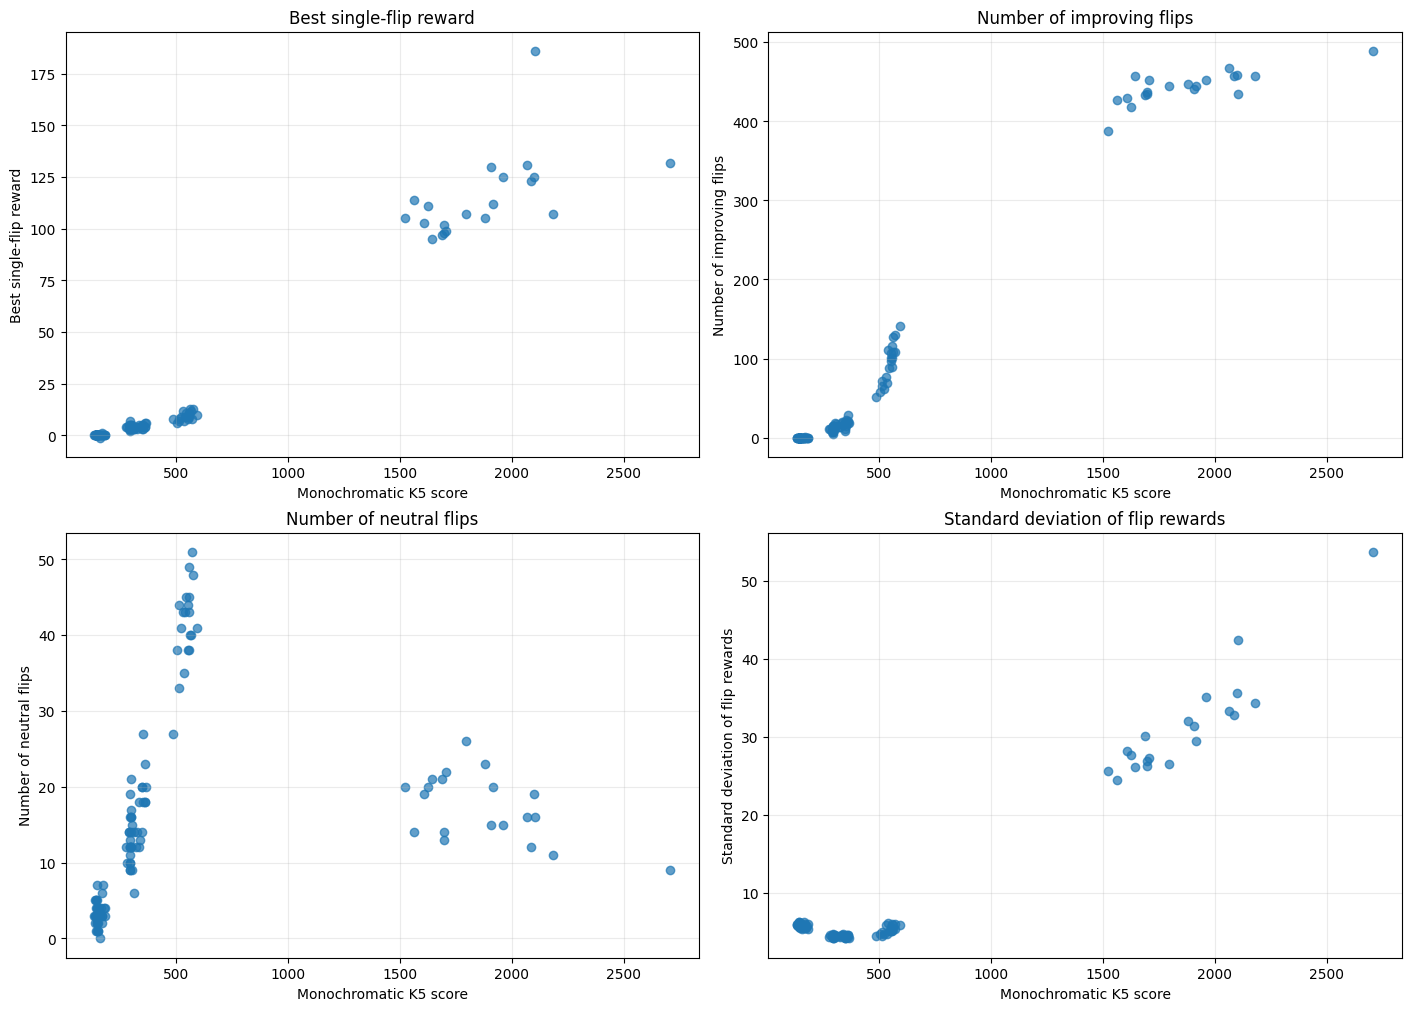

In [6]:
# How the ordinary action landscape changes as Ramsey score falls.
fig, axes = plt.subplots(2, 2, figsize=(14, 10), constrained_layout=True)

plots = (
    ('landscape_best_reward', 'Best single-flip reward'),
    ('landscape_improving_actions', 'Number of improving flips'),
    ('landscape_neutral_actions', 'Number of neutral flips'),
    ('landscape_std_reward', 'Standard deviation of flip rewards'),
)

for ax, (column, title) in zip(axes.flat, plots):
    ax.scatter(
        landscape_frame['score'],
        landscape_frame[column],
        alpha=0.7,
    )
    ax.set_xlabel('Monochromatic K5 score')
    ax.set_ylabel(title)
    ax.set_title(title)
    ax.grid(alpha=0.25)

plt.show()

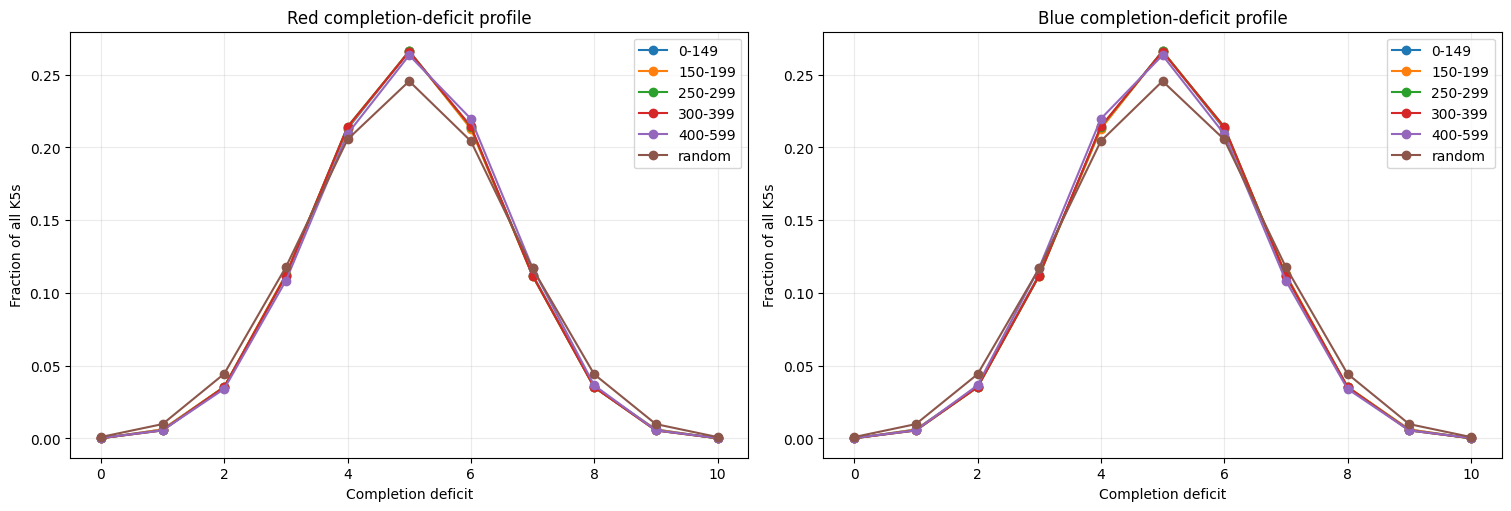

In [7]:
# Completion-deficit evolution. Red and blue stay separate.
# Each line is the mean fraction of all K5s in a deficit bin.
fig, axes = plt.subplots(1, 2, figsize=(15, 5), constrained_layout=True)
clique_count = graph.subgraph_index(5).clique_count

for tier in tier_order:
    tier_rows = landscape_frame[landscape_frame['tier'] == tier]
    if tier_rows.empty:
        continue

    red_profiles = np.asarray([
        snapshots[state_id].red_deficit_histogram
        for state_id in tier_rows['state_id']
    ], dtype=np.float64)
    blue_profiles = np.asarray([
        snapshots[state_id].blue_deficit_histogram
        for state_id in tier_rows['state_id']
    ], dtype=np.float64)

    deficits = np.arange(red_profiles.shape[1])
    axes[0].plot(
        deficits,
        red_profiles.mean(axis=0) / clique_count,
        marker='o',
        label=tier,
    )
    axes[1].plot(
        deficits,
        blue_profiles.mean(axis=0) / clique_count,
        marker='o',
        label=tier,
    )

axes[0].set_title('Red completion-deficit profile')
axes[1].set_title('Blue completion-deficit profile')

for ax in axes:
    ax.set_xlabel('Completion deficit')
    ax.set_ylabel('Fraction of all K5s')
    ax.grid(alpha=0.25)
    ax.legend()

plt.show()

In [8]:
# At the frontier, exact greedy reward often ties at zero. This table
# exposes information that exact reward discards: how tied best actions
# reshape red and blue deficit-one pressure.
frontier = landscape_frame[landscape_frame['tier'] == tier_order[0]]
counterfactual_rows = []

for state_id in frontier['state_id']:
    landscape = landscapes[state_id]
    rewards = landscape.exact_rewards
    best_reward = int(rewards.max())
    best_edges = np.flatnonzero(rewards == best_reward)

    for edge in best_edges:
        edge = int(edge)
        counterfactual_rows.append({
            'state_id': state_id,
            'score': snapshots[state_id].score,
            'edge': edge,
            'color': 'R' if landscape.source_state.colors[edge] == 0 else 'B',
            'reward': int(rewards[edge]),
            'red_destroyed': int(landscape.red_violations_destroyed[edge]),
            'red_created': int(landscape.red_violations_created[edge]),
            'blue_destroyed': int(landscape.blue_violations_destroyed[edge]),
            'blue_created': int(landscape.blue_violations_created[edge]),
            'delta_red_deficit_1': int(landscape.red_deficit_one_deltas[edge]),
            'delta_blue_deficit_1': int(landscape.blue_deficit_one_deltas[edge]),
            'delta_red_deficit_2': int(landscape.red_deficit_two_deltas[edge]),
            'delta_blue_deficit_2': int(landscape.blue_deficit_two_deltas[edge]),
        })

counterfactual_frame = pd.DataFrame(counterfactual_rows)
display(counterfactual_frame)

,state_id,score,edge,color,reward,red_destroyed,red_created,blue_destroyed,blue_created,delta_red_deficit_1,delta_blue_deficit_1,delta_red_deficit_2,delta_blue_deficit_2
0,2652,146,421,B,0,0,4,4,0,85,-154,429,-546
1,2652,146,450,B,0,0,2,2,0,87,-111,430,-531
2,2652,146,521,R,0,1,0,0,1,-100,90,-452,534
3,2652,146,686,R,0,3,0,0,3,-84,100,-482,482
4,2652,146,847,R,0,7,0,0,7,-105,179,-433,579
...,...,...,...,...,...,...,...,...,...,...,...,...,...
58,2985,147,508,B,0,0,2,2,0,71,-49,538,-428
59,2985,147,559,R,0,3,0,0,3,-86,101,-415,576
60,2870,146,425,R,0,2,0,0,2,-83,92,-503,525
61,2870,146,503,R,0,1,0,0,1,-118,136,-550,544


## What comes next

Do not choose weights yet. First look for measurements that change consistently with score tier and, especially, measurements that distinguish tied best/neutral moves at the frontier.

The next controlled experiment should start from equal-score states, apply competing tie-breaking objectives under the same action budget, and measure future best-score reduction. That separates correlation with current score from predictive value for future search.

In [9]:
metric_store.close()
archive.close()
print('Archive and metric store closed.')

Archive and metric store closed.


In [10]:
# Final Experimental Report
#
# Produces a plain-text report suitable for copying directly
# into ChatGPT for analysis.

print()
print("=" * 100)
print("RAMSEY ACTION LANDSCAPE EXPERIMENT")
print("=" * 100)

print()
print("EXPERIMENT CONFIGURATION")
print("-" * 100)
print(f"Vertices:                 {N_VERTICES}")
print(f"Edges:                    {graph.number_of_edges:,}")
print(f"K5s:                      {graph.subgraph_index(5).clique_count:,}")
print(f"Random seed:              {RANDOM_SEED}")
print(f"Samples per archive tier: {SAMPLES_PER_TIER}")
print(f"Random samples:           {RANDOM_SAMPLES}")
print(f"States analyzed:          {len(landscape_frame)}")
print(f"Analysis time:            {analysis_elapsed:.3f}s")


# ------------------------------------------------------------------
# Tier Summary
# ------------------------------------------------------------------

print()
print("=" * 100)
print("1. SCORE-TIER SUMMARY")
print("=" * 100)

tier_report_columns = [
    "score",
    "red_violations",
    "blue_violations",
    "red_deficit_1",
    "blue_deficit_1",
    "max_vertex_violation_load",
    "max_edge_violation_load",
    "shared_edge_violation_pairs",
    "landscape_best_reward",
    "landscape_improving_actions",
    "landscape_neutral_actions",
    "landscape_worsening_actions",
    "landscape_mean_reward",
    "landscape_std_reward",
]

for tier in tier_order:
    tier_data = landscape_frame[
        landscape_frame["tier"] == tier
    ]

    if tier_data.empty:
        continue

    print()
    print(f"TIER: {tier}")
    print(f"States: {len(tier_data)}")
    print("-" * 100)

    for column in tier_report_columns:
        values = tier_data[column].astype(float)

        print(
            f"{column:36s} "
            f"mean={values.mean():10.3f}  "
            f"median={values.median():10.3f}  "
            f"std={values.std():10.3f}  "
            f"min={values.min():10.3f}  "
            f"max={values.max():10.3f}"
        )


# ------------------------------------------------------------------
# Completion-Deficit Evolution
# ------------------------------------------------------------------

print()
print("=" * 100)
print("2. COMPLETION-DEFICIT PROFILES")
print("=" * 100)

for tier in tier_order:
    tier_data = landscape_frame[
        landscape_frame["tier"] == tier
    ]

    if tier_data.empty:
        continue

    red_profiles = np.asarray(
        [
            snapshots[state_id].red_deficit_histogram
            for state_id in tier_data["state_id"]
        ],
        dtype=np.float64,
    )

    blue_profiles = np.asarray(
        [
            snapshots[state_id].blue_deficit_histogram
            for state_id in tier_data["state_id"]
        ],
        dtype=np.float64,
    )

    red_mean = red_profiles.mean(axis=0)
    blue_mean = blue_profiles.mean(axis=0)

    print()
    print(f"TIER: {tier}")
    print("-" * 100)
    print(
        "deficit       "
        "red_mean       "
        "blue_mean"
    )

    for deficit in range(red_profiles.shape[1]):
        print(
            f"{deficit:7d}  "
            f"{red_mean[deficit]:13.2f}  "
            f"{blue_mean[deficit]:13.2f}"
        )


# ------------------------------------------------------------------
# Action-Landscape Reward Quantiles
# ------------------------------------------------------------------

print()
print("=" * 100)
print("3. SINGLE-EDGE ACTION LANDSCAPE")
print("=" * 100)

for tier in tier_order:
    tier_data = landscape_frame[
        landscape_frame["tier"] == tier
    ]

    if tier_data.empty:
        continue

    reward_sets = [
        landscapes[state_id].exact_rewards
        for state_id in tier_data["state_id"]
    ]

    rewards = np.concatenate(
        reward_sets
    ).astype(np.float64)

    quantiles = np.quantile(
        rewards,
        [
            0.00,
            0.05,
            0.25,
            0.50,
            0.75,
            0.95,
            1.00,
        ],
    )

    print()
    print(f"TIER: {tier}")
    print(f"Actions examined: {len(rewards):,}")

    print(
        "reward quantiles: "
        f"min={quantiles[0]:+.1f}, "
        f"p05={quantiles[1]:+.1f}, "
        f"p25={quantiles[2]:+.1f}, "
        f"median={quantiles[3]:+.1f}, "
        f"p75={quantiles[4]:+.1f}, "
        f"p95={quantiles[5]:+.1f}, "
        f"max={quantiles[6]:+.1f}"
    )

    print(
        "action signs: "
        f"positive={np.count_nonzero(rewards > 0):,}, "
        f"neutral={np.count_nonzero(rewards == 0):,}, "
        f"negative={np.count_nonzero(rewards < 0):,}"
    )


# ------------------------------------------------------------------
# Individual State Fingerprints
# ------------------------------------------------------------------

print()
print("=" * 100)
print("4. INDIVIDUAL STATE RESULTS")
print("=" * 100)

state_columns = [
    "state_id",
    "tier",
    "score",
    "red_violations",
    "blue_violations",
    "red_deficit_1",
    "blue_deficit_1",
    "max_vertex_violation_load",
    "max_edge_violation_load",
    "shared_edge_violation_pairs",
    "landscape_best_reward",
    "landscape_improving_actions",
    "landscape_neutral_actions",
    "landscape_worsening_actions",
    "landscape_mean_reward",
    "landscape_std_reward",
]

print(
    landscape_frame[
        state_columns
    ].to_string(
        index=False,
    )
)


# ------------------------------------------------------------------
# Frontier Counterfactual Actions
# ------------------------------------------------------------------

print()
print("=" * 100)
print("5. FRONTIER BEST-ACTION COUNTERFACTUALS")
print("=" * 100)

if counterfactual_frame.empty:
    print("No frontier counterfactual actions.")
else:
    print(
        counterfactual_frame.to_string(
            index=False,
        )
    )


# ------------------------------------------------------------------
# Counterfactual Summary
# ------------------------------------------------------------------

print()
print("=" * 100)
print("6. FRONTIER COUNTERFACTUAL SUMMARY")
print("=" * 100)

if not counterfactual_frame.empty:
    counterfactual_columns = [
        "reward",
        "red_destroyed",
        "red_created",
        "blue_destroyed",
        "blue_created",
        "delta_red_deficit_1",
        "delta_blue_deficit_1",
        "delta_red_deficit_2",
        "delta_blue_deficit_2",
    ]

    for column in counterfactual_columns:
        values = counterfactual_frame[
            column
        ].astype(float)

        print(
            f"{column:28s} "
            f"mean={values.mean():9.3f}  "
            f"median={values.median():9.3f}  "
            f"min={values.min():9.3f}  "
            f"max={values.max():9.3f}"
        )


print()
print("=" * 100)
print("END OF EXPERIMENT")
print("=" * 100)


RAMSEY ACTION LANDSCAPE EXPERIMENT

EXPERIMENT CONFIGURATION
----------------------------------------------------------------------------------------------------
Vertices:                 43
Edges:                    903
K5s:                      962,598
Random seed:              202608071
Samples per archive tier: 20
Random samples:           20
States analyzed:          120
Analysis time:            20.227s

1. SCORE-TIER SUMMARY

TIER: 0-149
States: 20
----------------------------------------------------------------------------------------------------
score                                mean=   144.650  median=   146.000  std=     3.703  min=   137.000  max=   149.000
red_violations                       mean=    76.300  median=    76.000  std=     5.750  min=    67.000  max=    89.000
blue_violations                      mean=    68.350  median=    68.000  std=     7.191  min=    56.000  max=    81.000
red_deficit_1                        mean=  5914.150  median=  5907.000  std= 